Conexión exitosa a la base de datos.
Dataset de clustering: (3961, 8)


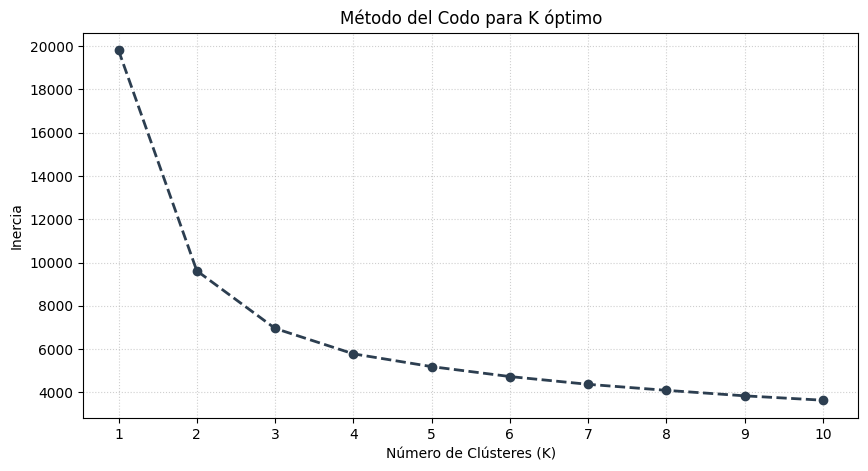

Silhouette Score para K=2: 0.4412
Silhouette Score para K=3: 0.3324
Silhouette Score para K=4: 0.2788

Perfil de clústeres (promedios):
Competencia COMPETENCIAS CIUDADANAS       COMUNICACIÓN ESCRITA        INGLÉS  \
                               mean count                 mean count    mean   
Cluster                                                                        
0                            137.07  2561               134.68  2561  147.81   
1                            164.38  1400               152.48  1400  179.76   

Competencia       LECTURA CRÍTICA       RAZONAMIENTO CUANTITATIVO        
            count            mean count                      mean count  
Cluster                                                                  
0            2561          144.34  2561                    138.31  2561  
1            1400          171.21  1400                    165.56  1400  


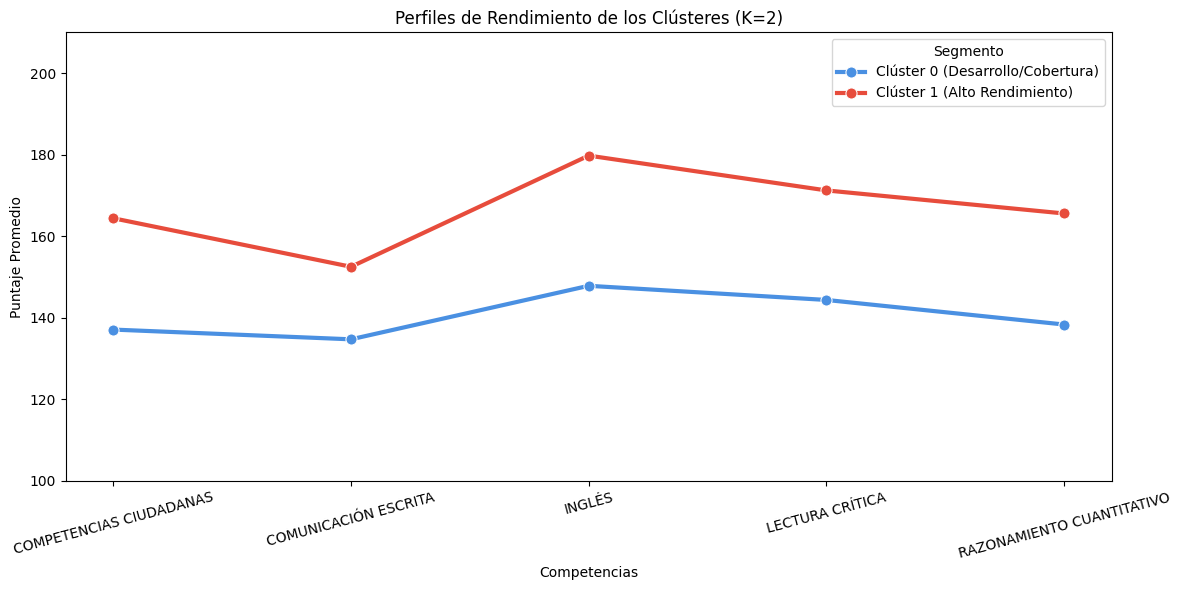

Dataset supervisado: (136, 7)

=== REPORTE DE CLASIFICACIÓN ===
                              precision    recall  f1-score   support

      Clúster 0 (Desarrollo)       0.89      0.89      0.89        18
Clúster 1 (Alto Rendimiento)       0.78      0.78      0.78         9

                    accuracy                           0.85        27
                   macro avg       0.83      0.83      0.83        27
                weighted avg       0.85      0.85      0.85        27



C:\Users\NaujAlkml\AppData\Local\Temp\ipykernel_2736\3238330650.py:193: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia, x='Importancia', y='Componente', palette='viridis')


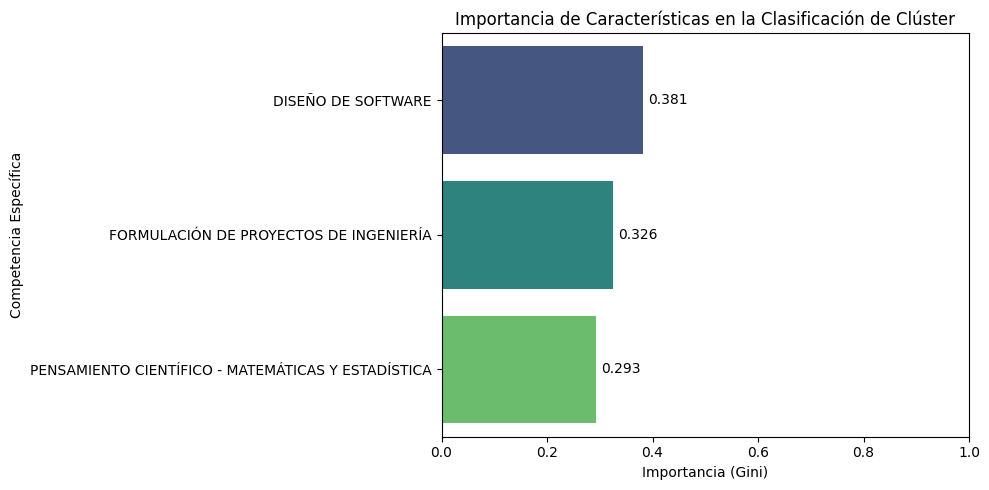

🧙‍♂️ ¡EL SOMBRERO SELECCIONADOR DE ML DICTA SU VEREDICTO!
🔮 Perfil técnico: Diseño SW=172, Formulación=160, Pensamiento Científico=177
🏆 ¡CLÚSTER 1! ALTO RENDIMIENTO NACIONAL
   Confianza: 99.00%


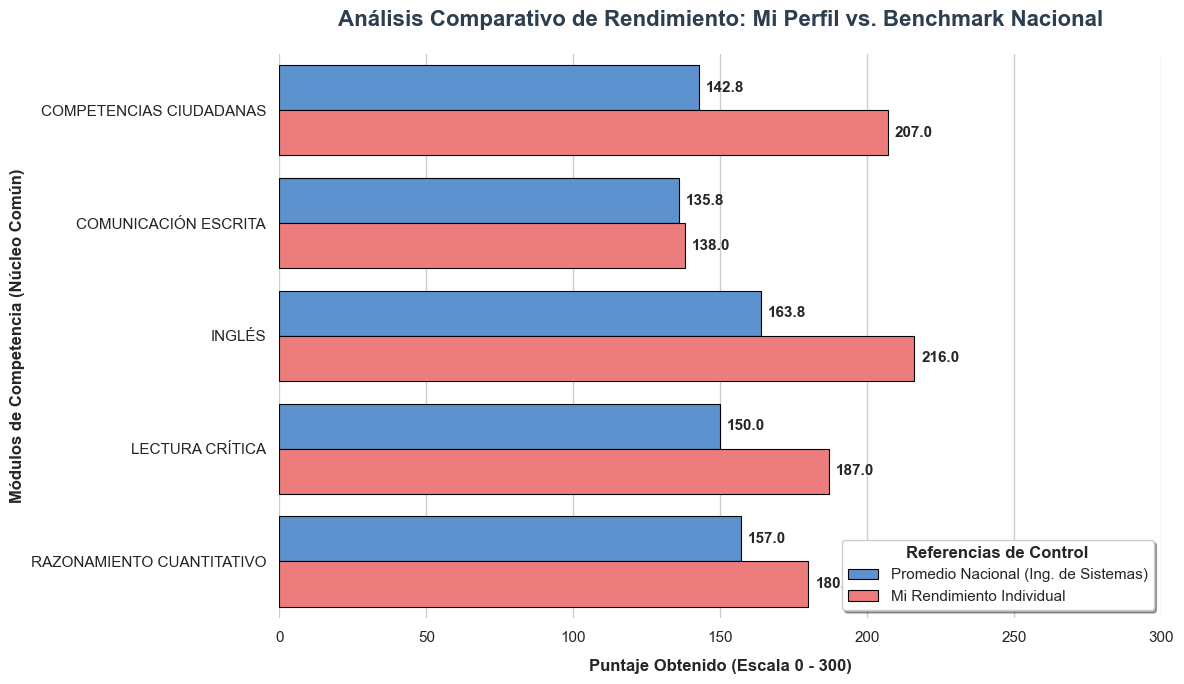

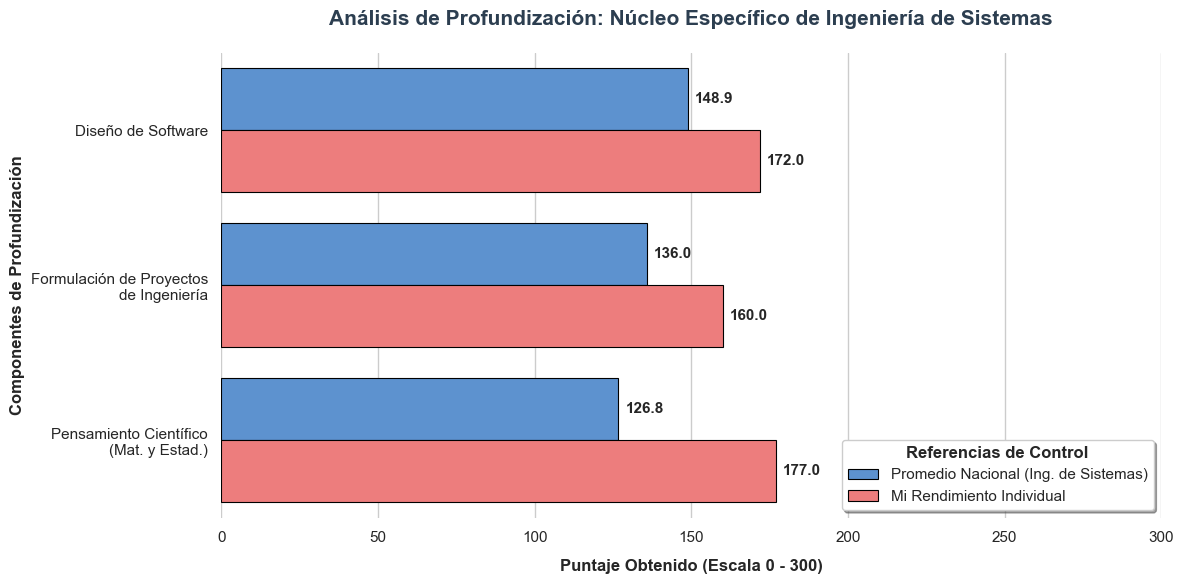

In [2]:
# =============================================================================
# MACHINE LEARNING: CLUSTERING Y CLASIFICACIÓN CON DATOS ICFES SABER PRO
# =============================================================================
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------------------------------------------------------
# 1. CONEXIÓN A LA BASE DE DATOS
# -----------------------------------------------------------------------------
conn = sqlite3.connect('saberpro_star_schema.db')
print("Conexión exitosa a la base de datos.")

# -----------------------------------------------------------------------------
# 2. EXTRACCIÓN DEL NÚCLEO COMÚN PARA CLUSTERING
# -----------------------------------------------------------------------------
query_nucleo_comun = """
SELECT 
    i.NOMBRE_INSTITUCION AS Universidad,
    i.NOMBRE_SEDE AS Sede,
    p.NOMBRE_PROGRAMA_ACAD AS Programa,
    q.NOMBRE_PRUEBA AS Competencia,
    AVG(f.PROMEDIO_PRUEBA) AS Promedio,
    SUM(f.CANTIDADEVALUADOS) AS Total_Evaluados
FROM FACT_RESULTADOS f
JOIN DIM_INSTITUCION i ON f.id_inst_sede = i.id_inst_sede
JOIN DIM_PROGRAMA p ON f.ID_PROGRAMA_ACAD = p.ID_PROGRAMA_ACAD
JOIN DIM_PRUEBA q ON f.id_prueba = q.id_prueba
WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO'
  AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
  AND f.PROMEDIO_PRUEBA IS NOT NULL
  AND q.NOMBRE_PRUEBA IN (
      'COMPETENCIAS CIUDADANAS',
      'COMUNICACIÓN ESCRITA',
      'INGLÉS',
      'LECTURA CRÍTICA',
      'RAZONAMIENTO CUANTITATIVO'
  )
GROUP BY Universidad, Sede, Programa, Competencia
HAVING Total_Evaluados >= 5;
"""

df_raw_clust = pd.read_sql(query_nucleo_comun, conn)

# Pivotar para tener una columna por competencia
df_features = df_raw_clust.pivot_table(
    index=['Universidad', 'Sede', 'Programa'],
    columns='Competencia',
    values='Promedio'
).reset_index()

# Eliminar filas con nulos (programas que no tienen todas las competencias)
df_features_clean = df_features.dropna().copy()
print(f"Dataset de clustering: {df_features_clean.shape}")

# -----------------------------------------------------------------------------
# 3. CLUSTERING (K-MEANS)
# -----------------------------------------------------------------------------
columnas_competencias = ['COMPETENCIAS CIUDADANAS', 'COMUNICACIÓN ESCRITA', 'INGLÉS', 'LECTURA CRÍTICA', 'RAZONAMIENTO CUANTITATIVO']
X = df_features_clean[columnas_competencias]

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Método del codo
inercias = []
k_valores = range(1, 11)
for k in k_valores:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(k_valores, inercias, marker='o', linestyle='--', color='#2C3E50', linewidth=2)
plt.title('Método del Codo para K óptimo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia')
plt.xticks(k_valores)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Silueta para K=2,3,4
for k in [2,3,4]:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_test.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"Silhouette Score para K={k}: {score:.4f}")

# Elegir K=2 (óptimo según codo y silueta)
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df_features_clean['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Perfil de clústeres
perfil_clusters = df_features_clean.groupby('Cluster')[columnas_competencias].agg(['mean', 'count']).round(2)
print("\nPerfil de clústeres (promedios):")
print(perfil_clusters)

# Visualización de perfiles
df_profile = df_features_clean.groupby('Cluster')[columnas_competencias].mean().T.reset_index()
df_profile_melted = df_profile.melt(id_vars='Competencia', var_name='Cluster', value_name='Promedio')
df_profile_melted['Clúster Identificado'] = df_profile_melted['Cluster'].map({0: 'Clúster 0 (Desarrollo/Cobertura)', 1: 'Clúster 1 (Alto Rendimiento)'})

plt.figure(figsize=(12,6))
sns.lineplot(data=df_profile_melted, x='Competencia', y='Promedio', hue='Clúster Identificado',
             marker='o', linewidth=3, markersize=8, palette=['#4A90E2', '#E74C3C'])
plt.title('Perfiles de Rendimiento de los Clústeres (K=2)')
plt.xlabel('Competencias')
plt.ylabel('Puntaje Promedio')
plt.ylim(100, 210)
plt.xticks(rotation=15)
plt.legend(title='Segmento')
plt.tight_layout()
plt.savefig('perfil_clusters.png', dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 4. CLASIFICACIÓN SUPERVISADA (RANDOM FOREST) PARA INGENIERÍA DE SISTEMAS
# -----------------------------------------------------------------------------
# Extraer datos específicos de Ingeniería de Sistemas
query_supervisado = """
SELECT 
    i.NOMBRE_INSTITUCION AS Universidad,
    i.NOMBRE_SEDE AS Sede,
    p.NOMBRE_PROGRAMA_ACAD AS Programa,
    q.NOMBRE_PRUEBA AS Competencia,
    AVG(f.PROMEDIO_PRUEBA) AS Promedio
FROM FACT_RESULTADOS f
JOIN DIM_INSTITUCION i ON f.id_inst_sede = i.id_inst_sede
JOIN DIM_PROGRAMA p ON f.ID_PROGRAMA_ACAD = p.ID_PROGRAMA_ACAD
JOIN DIM_PRUEBA q ON f.id_prueba = q.id_prueba
WHERE f.AGREGACION = 'PROGRAMA_ACÁDEMICO'
  AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
  AND f.PROMEDIO_PRUEBA IS NOT NULL
  AND p.NOMBRE_PROGRAMA_ACAD LIKE '%INGENIERÍA DE SISTEMAS%'
  AND q.NOMBRE_PRUEBA IN (
      'DISEÑO DE SOFTWARE',
      'FORMULACIÓN DE PROYECTOS DE INGENIERÍA',
      'PENSAMIENTO CIENTÍFICO - MATEMÁTICAS Y ESTADÍSTICA'
  )
GROUP BY Universidad, Sede, Programa, Competencia;
"""

df_raw_sup = pd.read_sql(query_supervisado, conn)
conn.close()

# Pivotar
df_pivot_sup = df_raw_sup.pivot_table(
    index=['Universidad', 'Sede', 'Programa'],
    columns='Competencia',
    values='Promedio'
).reset_index()

# Unir con los clústeres obtenidos anteriormente
df_target = df_features_clean[['Universidad', 'Sede', 'Programa', 'Cluster']]
df_ml = pd.merge(df_pivot_sup, df_target, on=['Universidad', 'Sede', 'Programa'], how='inner')
print(f"Dataset supervisado: {df_ml.shape}")

# Preparar features y target
features_especificas = ['DISEÑO DE SOFTWARE', 'FORMULACIÓN DE PROYECTOS DE INGENIERÍA', 'PENSAMIENTO CIENTÍFICO - MATEMÁTICAS Y ESTADÍSTICA']
df_ml_ready = df_ml.dropna(subset=features_especificas).copy()
X_sup = df_ml_ready[features_especificas]
y_sup = df_ml_ready['Cluster']

# Dividir
X_train, X_test, y_train, y_test = train_test_split(X_sup, y_sup, test_size=0.2, random_state=42, stratify=y_sup)

# Entrenar Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# Evaluar
y_pred = rf_model.predict(X_test)
print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred, target_names=['Clúster 0 (Desarrollo)', 'Clúster 1 (Alto Rendimiento)']))

# Importancia de características
importancias = rf_model.feature_importances_
df_importancia = pd.DataFrame({
    'Componente': features_especificas,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=df_importancia, x='Importancia', y='Componente', palette='viridis')
plt.title('Importancia de Características en la Clasificación de Clúster')
plt.xlabel('Importancia (Gini)')
plt.ylabel('Competencia Específica')
plt.xlim(0, 1)
for i, row in df_importancia.iterrows():
    plt.text(row['Importancia'] + 0.01, i, f"{row['Importancia']:.3f}", va='center')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 5. FUNCIÓN "SOMBRERO SELECCIONADOR" (PREDICCIÓN INDIVIDUAL)
# -----------------------------------------------------------------------------
def sombrero_seleccionador(diseno_sw, formulacion_proj, pensamiento_cient):
    mis_datos = pd.DataFrame([{
        'DISEÑO DE SOFTWARE': diseno_sw,
        'FORMULACIÓN DE PROYECTOS DE INGENIERÍA': formulacion_proj,
        'PENSAMIENTO CIENTÍFICO - MATEMÁTICAS Y ESTADÍSTICA': pensamiento_cient
    }])
    clase_predicha = rf_model.predict(mis_datos)[0]
    probabilidades = rf_model.predict_proba(mis_datos)[0]
    print("="*60)
    print("🧙‍♂️ ¡EL SOMBRERO SELECCIONADOR DE ML DICTA SU VEREDICTO!")
    print("="*60)
    print(f"🔮 Perfil técnico: Diseño SW={diseno_sw}, Formulación={formulacion_proj}, Pensamiento Científico={pensamiento_cient}")
    if clase_predicha == 1:
        print("🏆 ¡CLÚSTER 1! ALTO RENDIMIENTO NACIONAL")
        print(f"   Confianza: {probabilidades[1]*100:.2f}%")
    else:
        print("🏢 ¡CLÚSTER 0! COBERTURA Y DESARROLLO REGIONAL")
        print(f"   Confianza: {probabilidades[0]*100:.2f}%")
    print("="*60)

# Prueba con tus puntajes
sombrero_seleccionador(diseno_sw=172, formulacion_proj=160, pensamiento_cient=177)

# -----------------------------------------------------------------------------
# 6. COMPARATIVA PERSONAL (NÚCLEO COMÚN Y ESPECÍFICO)
# -----------------------------------------------------------------------------
# 6.1. Conexión y consulta analítica base
conn = sqlite3.connect('saberpro_star_schema.db')

query_comparativa = """
SELECT 
    q.NOMBRE_PRUEBA AS Competencia,
    ROUND(AVG(f.PROMEDIO_PRUEBA), 2) AS Promedio_Nacional_Sistemas
FROM FACT_RESULTADOS f
JOIN DIM_PROGRAMA p ON f.ID_PROGRAMA_ACAD = p.ID_PROGRAMA_ACAD
JOIN DIM_PRUEBA q ON f.id_prueba = q.id_prueba
WHERE p.NOMBRE_PROGRAMA_ACAD LIKE '%INGENIERÍA DE SISTEMAS%'
  AND f.AGREGACION = 'PROGRAMA_ACÁDEMICO'
  AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
  AND f.PROMEDIO_PRUEBA IS NOT NULL
  AND q.NOMBRE_PRUEBA IN (
      'COMPETENCIAS CIUDADANAS',
      'COMUNICACIÓN ESCRITA',
      'INGLÉS',
      'LECTURA CRÍTICA',
      'RAZONAMIENTO CUANTITATIVO'
  )
GROUP BY q.NOMBRE_PRUEBA;
"""

df_comp = pd.read_sql(query_comparativa, conn)
conn.close()

# 6.2. Tus puntajes del núcleo común mapeados
mis_puntajes_comunes = {
    'COMUNICACIÓN ESCRITA': 138,
    'RAZONAMIENTO CUANTITATIVO': 180,
    'LECTURA CRÍTICA': 187,
    'COMPETENCIAS CIUDADANAS': 207,
    'INGLÉS': 216
}

# Filtrar el dataframe para que solo contenga el núcleo común y mapear tus puntajes
df_comp['Mi_Puntaje'] = df_comp['Competencia'].map(mis_puntajes_comunes)
df_plot = df_comp.dropna(subset=['Mi_Puntaje']).copy()

# 6.3. Reestructurar el DataFrame (Melt) para facilitar el graficado con Seaborn
df_melted = df_plot.melt(
    id_vars=['Competencia'], 
    value_vars=['Promedio_Nacional_Sistemas', 'Mi_Puntaje'],
    var_name='Tipo_Puntaje', 
    value_name='Puntaje'
)

# Renombrar las etiquetas de las leyendas para que luzcan profesionales
df_melted['Tipo_Puntaje'] = df_melted['Tipo_Puntaje'].map({
    'Promedio_Nacional_Sistemas': 'Promedio Nacional (Ing. de Sistemas)',
    'Mi_Puntaje': 'Mi Rendimiento Individual'
})

# 6.4. Configuración Estética del Gráfico (Estilo Portafolio)
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Paleta corporativa: Azul profesional para la referencia nacional, Naranja/Coral para destacar tu puntaje
colores = ['#4A90E2', '#FF6B6B']

ax = sns.barplot(
    data=df_melted, 
    y='Competencia', 
    x='Puntaje', 
    hue='Tipo_Puntaje', 
    palette=colores,
    edgecolor='black',
    linewidth=0.8
)

# 6.5. Agregar los valores numéricos exactos en la punta de cada barra (Data Labels)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5, fontweight='bold', fontsize=11)

# Personalización de títulos y etiquetas
plt.title('Análisis Comparativo de Rendimiento: Mi Perfil vs. Benchmark Nacional', fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel('Puntaje Obtenido (Escala 0 - 300)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Módulos de Competencia (Núcleo Común)', fontsize=12, fontweight='bold')
plt.xlim(0, 300) # El límite máximo de la prueba Saber Pro

# Ajustes de diseño de la leyenda y bordes
plt.legend(title='Referencias de Control', title_fontproperties={'weight':'bold'}, loc='lower right', frameon=True, shadow=True)
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Guardar la gráfica automáticamente como imagen para la documentación del portafolio
plt.savefig('comparativa_rendimiento_saberpro.png', dpi=300)

# Mostrar el gráfico en el Notebook
plt.show()

# 6a.1. Conexión a la base de datos portátil
conn = sqlite3.connect('saberpro_star_schema.db')

# Consulta analítica adaptada para capturar los componentes específicos de ingeniería
query_especifico = """
SELECT 
    q.NOMBRE_PRUEBA AS Competencia,
    ROUND(AVG(f.PROMEDIO_PRUEBA), 2) AS Promedio_Nacional_Sistemas
FROM FACT_RESULTADOS f
JOIN DIM_PROGRAMA p ON f.ID_PROGRAMA_ACAD = p.ID_PROGRAMA_ACAD
JOIN DIM_PRUEBA q ON f.id_prueba = q.id_prueba
WHERE p.NOMBRE_PROGRAMA_ACAD LIKE '%INGENIERÍA DE SISTEMAS%'
  AND f.AGREGACION = 'PROGRAMA_ACÁDEMICO'
  AND f.MEDIDA_AGREGACION = 'PUNTAJE_PRUEBA'
  AND f.PROMEDIO_PRUEBA IS NOT NULL
  AND q.NOMBRE_PRUEBA IN (
      'DISEÑO DE SOFTWARE',
      'FORMULACIÓN DE PROYECTOS DE INGENIERÍA',
      'PENSAMIENTO CIENTÍFICO - MATEMÁTICAS Y ESTADÍSTICA'
  )
GROUP BY q.NOMBRE_PRUEBA;
"""

df_esp = pd.read_sql(query_especifico, conn)
conn.close()

# 6a.2. Diccionario con tus puntajes reales del núcleo específico
mis_puntajes_especificos = {
    'FORMULACIÓN DE PROYECTOS DE INGENIERÍA': 160,
    'PENSAMIENTO CIENTÍFICO - MATEMÁTICAS Y ESTADÍSTICA': 177,
    'DISEÑO DE SOFTWARE': 172
}

# Si por temas de acentos o mayúsculas la base de datos guardó los nombres ligeramente distintos,
# este mapeo flexible asegura que coincidan buscando subcadenas clave:
def asignar_mi_puntaje(nombre_prueba):
    for clave, valor in mis_puntajes_especificos.items():
        if clave.split(' - ')[0] in nombre_prueba: # Compara la primera parte del nombre
            return valor
    return None

df_esp['Mi_Puntaje'] = df_esp['Competencia'].apply(asignar_mi_puntaje)
df_plot_esp = df_esp.dropna(subset=['Mi_Puntaje']).copy()

# 6a.3. Formatear datos para el diseño de Seaborn (Melt)
df_melted_esp = df_plot_esp.melt(
    id_vars=['Competencia'], 
    value_vars=['Promedio_Nacional_Sistemas', 'Mi_Puntaje'],
    var_name='Tipo_Puntaje', 
    value_name='Puntaje'
)

df_melted_esp['Tipo_Puntaje'] = df_melted_esp['Tipo_Puntaje'].map({
    'Promedio_Nacional_Sistemas': 'Promedio Nacional (Ing. de Sistemas)',
    'Mi_Puntaje': 'Mi Rendimiento Individual'
})

# Acortar los nombres largos de las competencias en el eje Y para mejorar la estética visual
def acortar_nombre(nombre):
    if 'PENSAMIENTO CIENTÍFICO' in nombre: return 'Pensamiento Científico\n(Mat. y Estad.)'
    if 'FORMULACIÓN DE PROYECTOS' in nombre: return 'Formulación de Proyectos\nde Ingeniería'
    if 'DISEÑO DE SOFTWARE' in nombre: return 'Diseño de Software'
    return nombre

df_melted_esp['Competencia_Corta'] = df_melted_esp['Competencia'].apply(acortar_nombre)

# 6a.4. Construcción Estética del Gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Mantenemos la consistencia cromática de tu marca personal (Azul vs Naranja/Coral)
colores_corporativos = ['#4A90E2', '#FF6B6B']

ax = sns.barplot(
    data=df_melted_esp, 
    y='Competencia_Corta', 
    x='Puntaje', 
    hue='Tipo_Puntaje', 
    palette=colores_corporativos,
    edgecolor='black',
    linewidth=0.8
)

# Insertar etiquetas numéricas en los extremos de las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5, fontweight='bold', fontsize=11)

# Personalización final del lienzo
plt.title('Análisis de Profundización: Núcleo Específico de Ingeniería de Sistemas', fontsize=15, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel('Puntaje Obtenido (Escala 0 - 300)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Componentes de Profundización', fontsize=12, fontweight='bold')
plt.xlim(0, 300)

plt.legend(title='Referencias de Control', title_fontproperties={'weight':'bold'}, loc='lower right', frameon=True, shadow=True)
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Guardar imagen para la sección técnica del portafolio
plt.savefig('comparativa_nucleo_especifico.png', dpi=300)
plt.show()